# Linear Regression Models

We want to determine how draft pick characters influence the following Chicago Bulls NBA season. We do this through running a linear regression model that will allow us to explore this relationship.

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Load data

In [11]:
data_path = '../data/processed/cleaned_bulls_data.csv'
df = pd.read_csv(data_path)

print('Loaded dataset with rows:', len(df), 'and columns:', len(df.columns))
df.head()

Loaded dataset with rows: 39 and columns: 51


,Season,Team,W,L,W/L%,Finish,SRS,Pace,Rel Pace,ORtg,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards,ROY
0,2025,Chicago Bulls,27,38,0.415,4,-4.08,101.7,2.3,113.2,...,0.0,0.0,0.0,0.5,0.0,0.0,0.5,0.0,NaN,0
1,2024,Chicago Bulls,39,43,0.476,5,-1.83,102.8,4.0,114.1,...,2.8,3.5,1.0,0.4,0.9,0.9,1.6,8.6,ROY-7,7
2,2022,Chicago Bulls,40,42,0.488,3,1.37,98.5,-0.6,113.5,...,0.7,1.0,0.6,0.3,0.1,0.2,0.6,2.2,NaN,0
3,2021,Chicago Bulls*,46,36,0.561,2,-0.38,98.3,0.1,113.2,...,3.7,4.6,1.4,0.9,0.6,1.4,1.8,9.2,NaN,0
4,2020,Chicago Bulls,31,41,0.431,3,-0.94,99.0,-0.2,111.1,...,3.7,4.6,1.4,0.9,0.6,1.4,1.8,9.2,NaN,0


In [3]:
df.columns

Index(['Season', 'Team', 'W', 'L', 'W/L%', 'Finish', 'SRS', 'Pace', 'Rel Pace',
       'ORtg', 'Rel ORtg', 'DRtg', 'Rel DRtg', 'Playoffs', 'Coaches', 'Top WS',
       'Year', 'Lg', 'Rd', 'Pk', 'Player', 'College', 'Age', 'Pos', 'G', 'GS',
       'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%',
       'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK',
       'TOV', 'PF', 'PTS', 'Awards', 'ROY'],
      dtype='str')

In [24]:
df_train = df[['W/L%', 'Rd', 'Pk', 'College', 'Age', 'Pos', 'G', 'GS',
       'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%',
       'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK',
       'TOV', 'PF', 'PTS', 'ROY']]

In [25]:
df_train["College"] = df_train["College"].fillna("None")

In [26]:
X_train, X_test, y_train, y_test = train_test_split(df_train.drop('W/L%', axis=1), df_train['W/L%'], test_size=0.2, random_state=42)

In [34]:
# create a linear regression pipeline
numeric_features = ['Rd', 'Pk', 'Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']
categorical_features = ['Pos']

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [ ]:
import os
folder_name = "../visuals"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

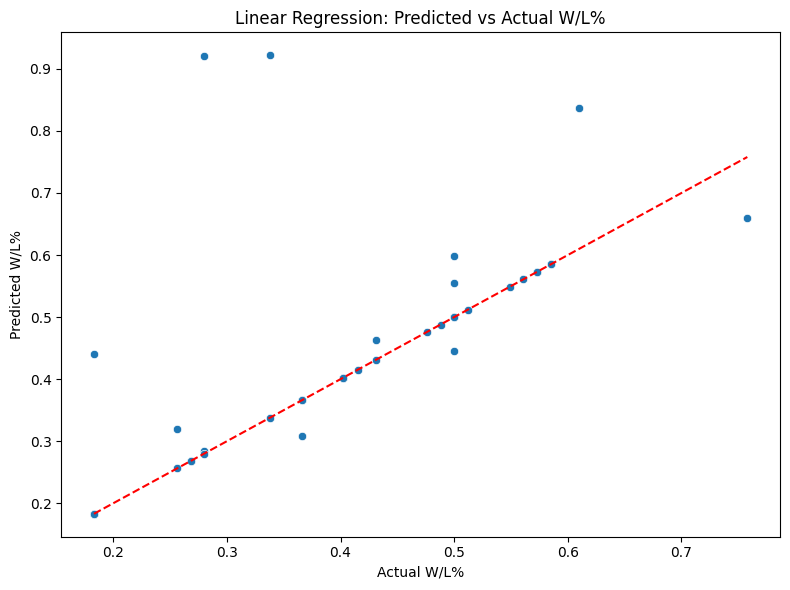

In [52]:
# linear regression plot of predicted vs actual
predictions = model.predict(df_train)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_train['W/L%'], y=predictions)
plt.xlabel('Actual W/L%')
plt.ylabel('Predicted W/L%')
plt.title('Linear Regression: Predicted vs Actual W/L%')
plt.plot([df_train['W/L%'].min(), df_train['W/L%'].max()], [df_train['W/L%'].min(), df_train['W/L%'].max()], 'r--')  # line for perfect predictions
plt.savefig(os.path.join("../visuals/linear_regression_predicted_vs_actual.png"))
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(os.path.join(folder_name, "linear_regression_predicted_vs_actual.png"))

<Figure size 640x480 with 0 Axes>

In [35]:
# check coefficients
feature_names = numeric_features + list(model.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features))
coefficients = model.named_steps['regressor'].coef_
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df = coef_df.sort_values(by='Coefficient', key=abs, ascending=False)
print(coef_df.head(10))

   Feature  Coefficient
7      FGA    -1.280556
12      2P     0.718480
15    eFG%    -0.678325
10     3PA     0.532141
5       MP     0.486797
13     2PA    -0.420870
27     PTS     0.360945
21     TRB     0.271565
29  Pos_PF     0.269035
8      FG%     0.261498


In [38]:
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print('Mean Squared Error:', mse)
print('R^2 Score:', r2)

Mean Squared Error: 0.10965954406476483
R^2 Score: -6.268599536995366


So our model sucks. Lets try a decision tree instead

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV


rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])  

param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]
}  

rf_model = GridSearchCV(rf_model, param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error').fit(X_train, y_train)

In [ ]:
# check rf predictions
rf_predictions = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print('Random Forest Mean Squared Error:', rf_mse)

Random Forest Mean Squared Error: 0.03590837636818
Random Forest R^2 Score: -1.3801266918441684


In [42]:
# check variable importance
importances = rf_model.best_estimator_.named_steps['regressor'].feature_importances_
feature_names = numeric_features + list(rf_model.best_estimator_.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features))
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df.head(10))

   Feature  Importance
3        G    0.105963
26      PF    0.099477
18     FT%    0.096309
11     3P%    0.087394
15    eFG%    0.080136
9       3P    0.077258
1       Pk    0.062913
28   Pos_C    0.045984
22     AST    0.039180
19     ORB    0.027097


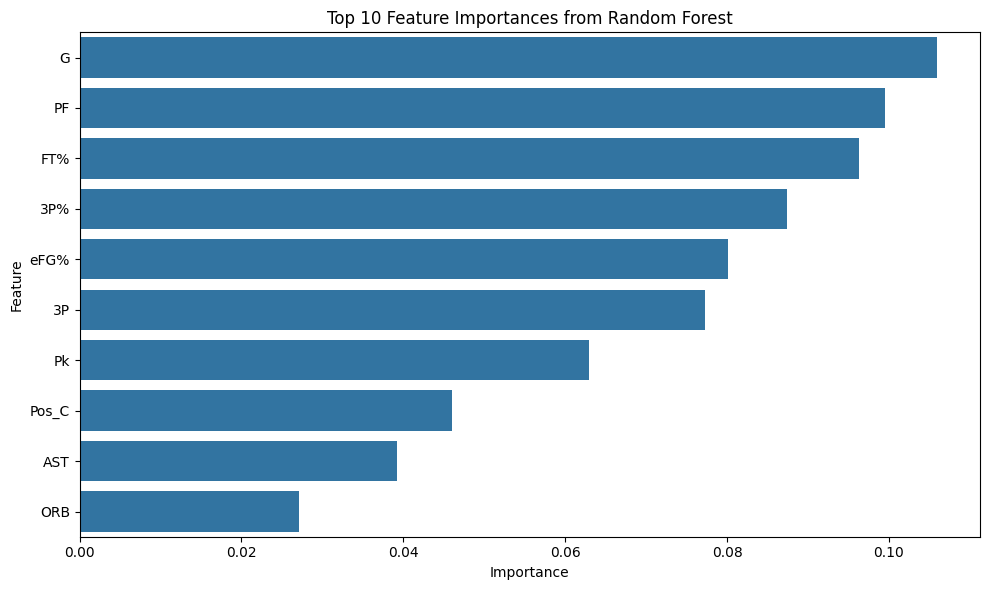

In [43]:
# visualize variable importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title('Top 10 Feature Importances from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

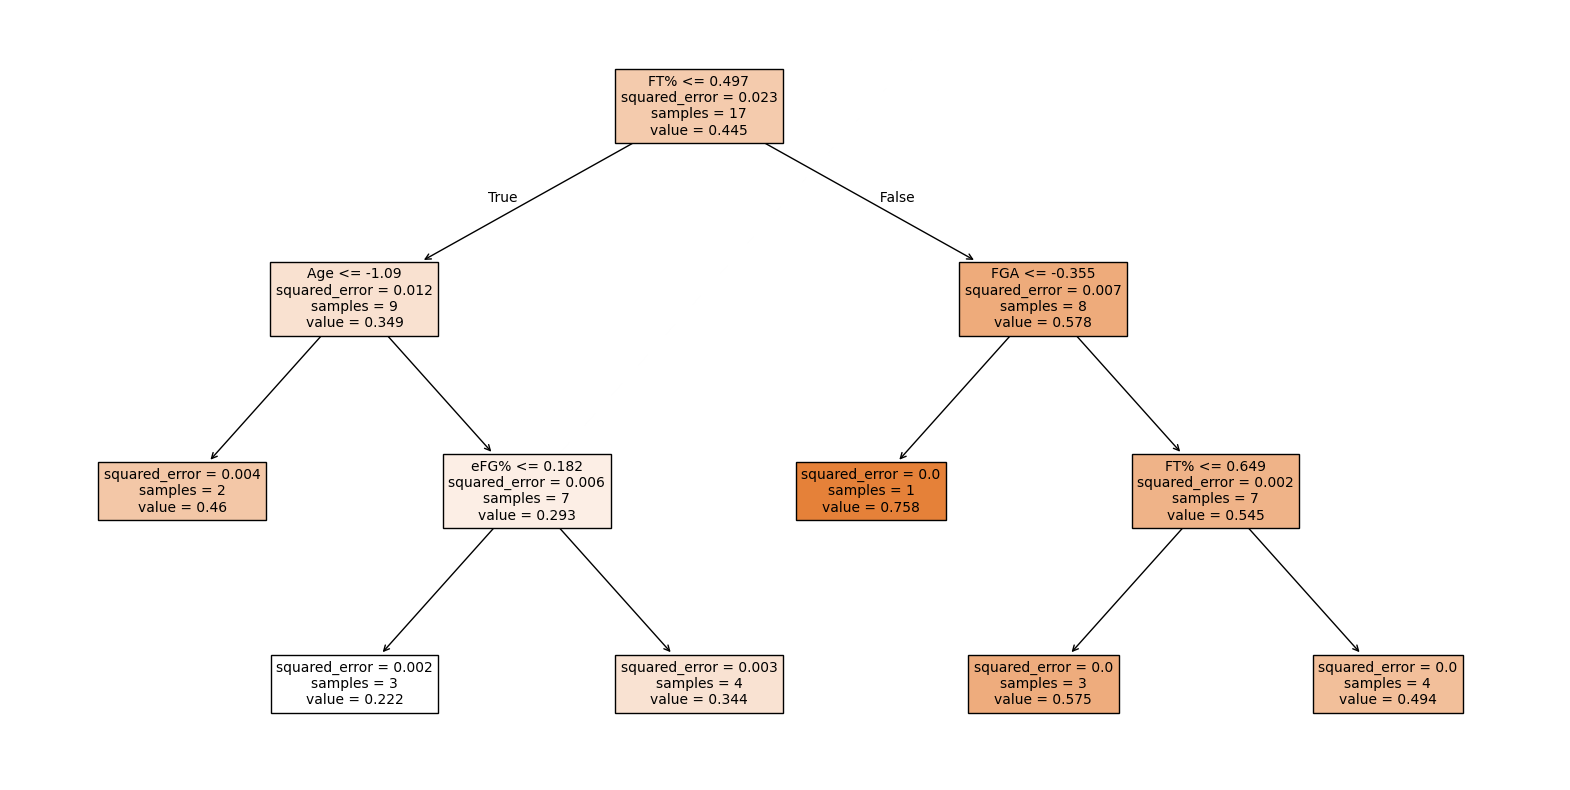

In [44]:
# visualize best tree
from sklearn.tree import plot_tree
best_rf = rf_model.best_estimator_.named_steps['regressor']
plt.figure(figsize=(20, 10))
plot_tree(best_rf.estimators_[0], filled=True, feature_names=feature_names, max_depth=3, fontsize=10)
plt.show() 